# 09 — Análisis de escalabilidad

## Objetivo

Analizar experimentalmente cómo cambia el tiempo de ejecución
cuando se modifica el número de procesos utilizados por la
simulación paralela.

Se estudiarán:

- 1 proceso.
- 2 procesos.
- 4 procesos.
- Otros valores disponibles según el hardware.

El objetivo es observar el comportamiento de la implementación
paralela y sus límites prácticos.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from src.data.loader import load_csv

from src.simulation.model import (
    NormalReturnModel,
)

from src.simulation.sequential import (
    SimulationConfig,
)

from src.simulation.parallel import (
    simulate_parallel_final_values,
)

from src.simulation.benchmark import (
    benchmark_simulation,
)

In [4]:
returns_data = load_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

model = NormalReturnModel(
    mean=returns_data["log_return"].mean(),
    volatility=returns_data["log_return"].std(),
)

In [5]:
SCENARIOS = 100_000

HORIZON = 252

INITIAL_VALUE = 100.0

SEED = 42

AVAILABLE_CPUS = (
    os.cpu_count() or 1
)

print(
    f"CPU lógicos disponibles: "
    f"{AVAILABLE_CPUS}"
)

CPU lógicos disponibles: 4


In [6]:
WORKER_COUNTS = [
    worker_count
    for worker_count in [1, 2, 4]
    if worker_count <= AVAILABLE_CPUS
]

print(
    WORKER_COUNTS
)

[1, 2, 4]


In [9]:
scalability_results = []

for workers in WORKER_COUNTS:

    config = SimulationConfig(
        scenarios=SCENARIOS,
        horizon=HORIZON,
        initial_value=INITIAL_VALUE,
        seed=SEED,
    )

    result = benchmark_simulation(
        simulation_function=lambda: simulate_parallel_final_values(
            model=model,
            config=config,
            workers=workers,
        ),
        scenarios=SCENARIOS,
    )

    scalability_results.append(
        {
            "workers": workers,
            "elapsed_seconds": result.elapsed_seconds,
        }
    )

    print(
        f"{workers} workers → "
        f"{result.elapsed_seconds:.4f} s"
    )

1 workers → 0.9742 s
2 workers → 0.7855 s
4 workers → 1.0490 s


In [10]:
scalability_table = pd.DataFrame(
    scalability_results
)

scalability_table

,workers,elapsed_seconds
0,1,0.974183
1,2,0.785490
2,4,1.048951


In [11]:
baseline_time = (
    scalability_table
    .iloc[0]["elapsed_seconds"]
)

scalability_table["speedup"] = (
    baseline_time
    / scalability_table["elapsed_seconds"]
)

scalability_table

,workers,elapsed_seconds,speedup
0,1,0.974183,1.000000
1,2,0.785490,1.240224
2,4,1.048951,0.928722


In [12]:
scalability_table["efficiency"] = (
    scalability_table["speedup"]
    / scalability_table["workers"]
)

scalability_table

,workers,elapsed_seconds,speedup,efficiency
0,1,0.974183,1.000000,1.000000
1,2,0.785490,1.240224,0.620112
2,4,1.048951,0.928722,0.232180


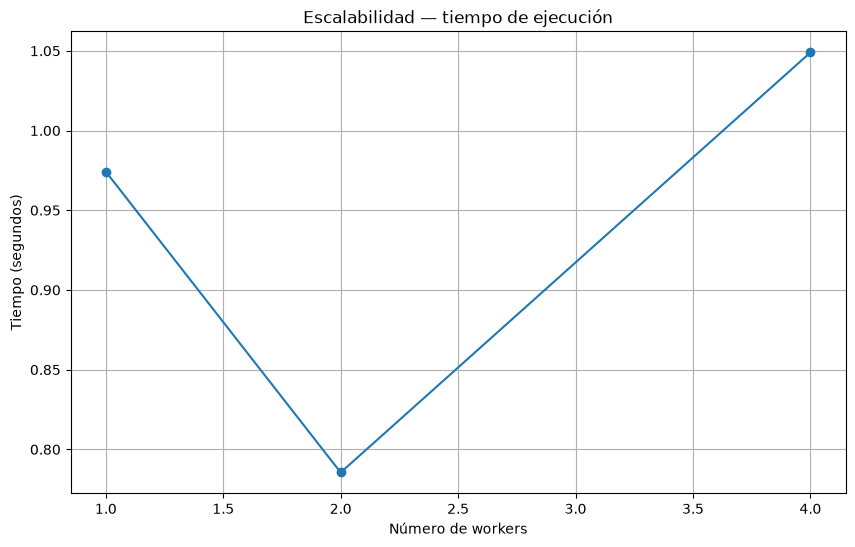

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    scalability_table["workers"],
    scalability_table["elapsed_seconds"],
    marker="o",
)

plt.title(
    "Escalabilidad — tiempo de ejecución"
)

plt.xlabel(
    "Número de workers"
)

plt.ylabel(
    "Tiempo (segundos)"
)

plt.grid(True)

plt.show()

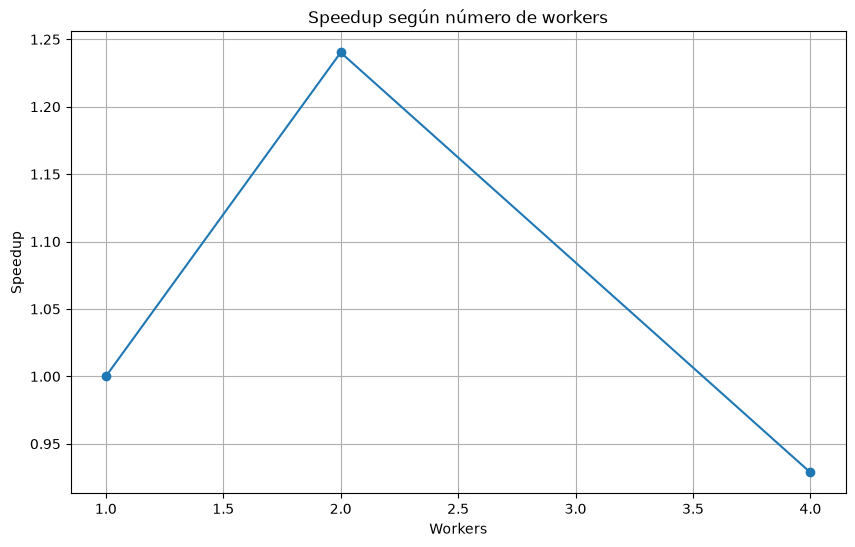

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    scalability_table["workers"],
    scalability_table["speedup"],
    marker="o",
)

plt.title(
    "Speedup según número de workers"
)

plt.xlabel(
    "Workers"
)

plt.ylabel(
    "Speedup"
)

plt.grid(True)

plt.show()

In [15]:
SCALABILITY_PATH = (
    PROJECT_ROOT
    / "results"
    / "benchmarks"
    / "scalability.csv"
)

scalability_table.to_csv(
    SCALABILITY_PATH,
    index=False,
)

print(
    SCALABILITY_PATH
)

c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\results\benchmarks\scalability.csv
